# Customer RFM Segmentation & Behavioral Profiling
**Objective**: Score customers along Recency, Frequency, and Monetary dimensions and evaluate the 8 behavioral customer segments.

C:\Users\Shubham Meena\AppData\Local\Temp\ipykernel_41720\3834901618.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary, y='rfm_segment', x='total_gmv', palette='mako')


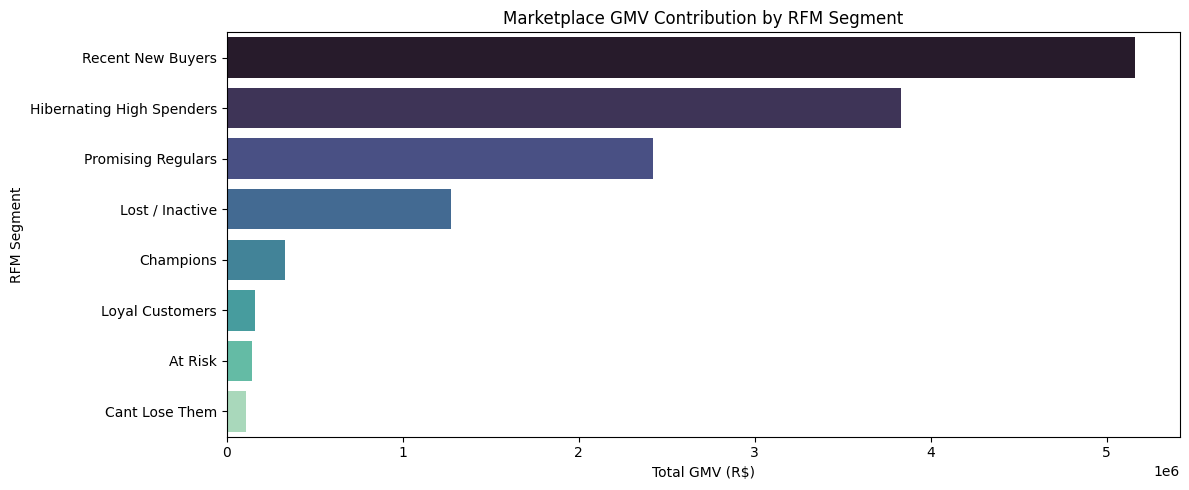

,rfm_segment,customers,total_gmv,avg_spend,avg_recency
7,Recent New Buyers,36665,5157830.55,140.674500,139.909832
3,Hibernating High Spenders,13763,3831489.71,278.390591,445.531933
6,Promising Regulars,18592,2421092.82,130.222290,270.180884
4,Lost / Inactive,22801,1275686.38,55.948703,446.075260
2,Champions,1235,333120.42,269.733134,138.161943
5,Loyal Customers,628,162780.85,259.205175,267.976115
0,At Risk,563,143477.78,254.845080,368.159858
1,Cant Lose Them,450,108273.41,240.607578,515.197778


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

proc_dir = r'../data/processed'
rfm = pd.read_csv(os.path.join(proc_dir, 'customer_rfm.csv'))

segment_summary = rfm.groupby('rfm_segment').agg(
    customers=('customer_unique_id', 'count'),
    total_gmv=('monetary', 'sum'),
    avg_spend=('monetary', 'mean'),
    avg_recency=('recency_days', 'mean')
).reset_index().sort_values('total_gmv', ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=segment_summary, y='rfm_segment', x='total_gmv', palette='mako')
plt.title('Marketplace GMV Contribution by RFM Segment')
plt.xlabel('Total GMV (R$)')
plt.ylabel('RFM Segment')
plt.tight_layout()
plt.show()
segment_summary